In [2]:
from Configurations.imports import *
from sklearn.datasets import make_blobs

In [5]:
# Creation of the dataset
X,y = make_blobs(n_samples=1000,n_features=2,centers=3, random_state=56)

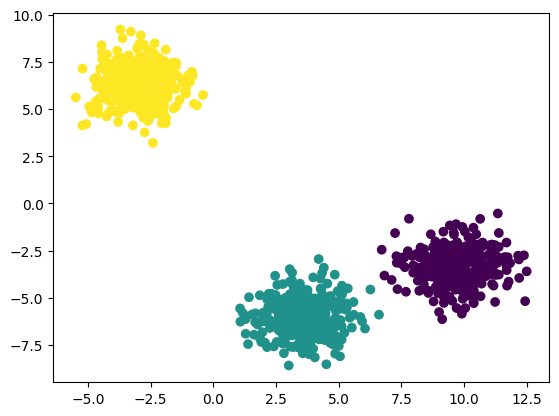

In [7]:
# visualization of the dataset
plt.scatter(X[:,0],X[:,1],c=y)

In [9]:
# train and test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=56)

In [10]:
# standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
# choosing the best k value by using elbow method
from sklearn.cluster import KMeans
wcss = []

for k in range(1,20):
    cluter = KMeans(n_clusters=k, init="k-means++")
    cluter.fit(x_train)
    wcss.append(cluter.inertia_)

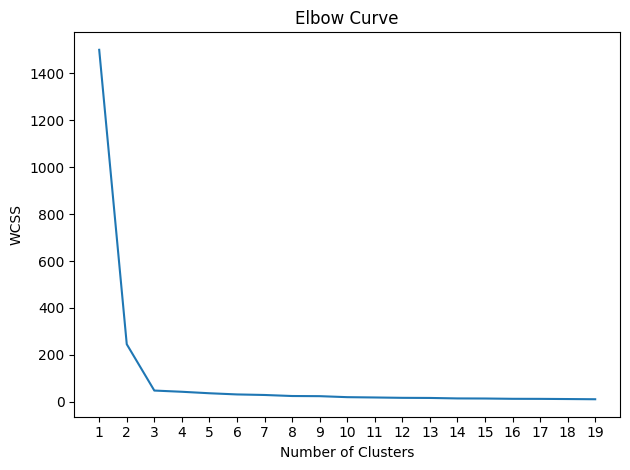

In [16]:
# plot the elbow curve
plt.plot(range(1,20),wcss)
plt.xticks(range(1,20))
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()

In [26]:
# Technique one to get the best k
from kneed import KneeLocator
kl = KneeLocator(range(1,20),wcss,curve="convex",direction="decreasing")

In [28]:
kl.elbow

np.int64(3)

In [35]:
# Technique 2: Silhouette Scoring
from sklearn.metrics import silhouette_score
silhouette_coeff = []

for k in range(2,20):
    cl = KMeans(n_clusters=k, init="k-means++")
    cl.fit(x_train)

    score = silhouette_score(x_train, cl.labels_)
    silhouette_coeff.append(score)

In [39]:
silhouette_coeff

[0.770917034973365,
 0.7924698362944167,
 0.5927706401618588,
 0.5133438452468662,
 0.30086031204164465,
 0.3151850220931041,
 0.3116051071983433,
 0.3167406090666328,
 0.3391415894019582,
 0.33078759664479473,
 0.3239402684421092,
 0.34391656106947976,
 0.3341302280703711,
 0.32870494452728116,
 0.3469900802642686,
 0.32811366739392744,
 0.3315184265844181,
 0.34877474791082075]

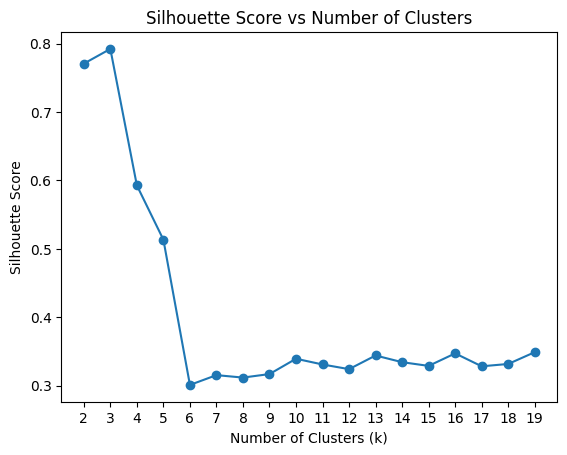

In [44]:
plt.plot(range(2,20), silhouette_coeff, marker='o')
plt.xticks(range(2,20))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

In [19]:
cluster = KMeans(n_clusters=3,init="k-means++")
y_train_pred = cluster.fit_predict(x_train)

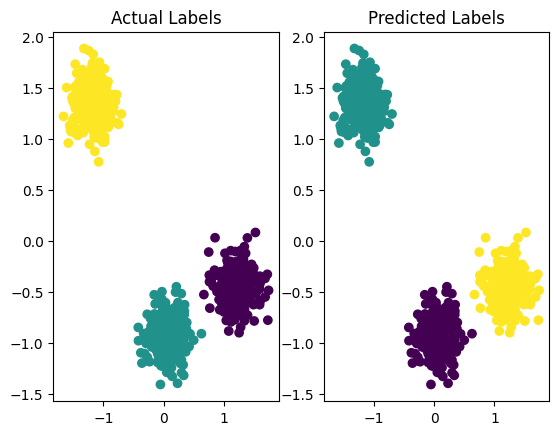

In [21]:
# vizualise both predicted and actual
plt.subplot(1,2,1)
plt.scatter(x_train[:,0], x_train[:,1], c=y_train)
plt.title("Actual Labels")

plt.subplot(1,2,2)
plt.scatter(x_train[:,0], x_train[:,1], c=y_train_pred)
plt.title("Predicted Labels")

plt.show()